# C5G7 Benchmark (2-D)

This 2-D benchmark is an adaptation of the [C5G7 benchmark](https://www.oecd-nea.org/jcms/pl_13548/benchmark-on-deterministic-transport-calculations-without-spatial-homogenisation?details=true). The multigroup cross section (MGXS) set was created using [OpenMC's benchmark C5G7 scripts](https://github.com/mit-crpg/benchmarks) with a $51\times 51$ regular mesh (the same size as one pincell). The MGXSs were then homogenized by material using flux weighting given the scalar flux on the $51\times 51$ mesh found by OpenMC. The result is a MGXS set of seven materials:

- $UO_2$ fuel,
- $7.0\%$ MOX fuel,
- $4.3\%$ MOX fuel,
- $8.7\%$ MOX fuel,
- guide tube,
- fission chamber,
- and moderator.

We use AMEn and GMRES to solve the neutron transport equation on a $I\times J$ regular mesh, where $I = J = 102$, with $G = 7$ energy groups and $N=4$ ordinates, totaling $N\times G\times (I + 1) \times (J + 1) = 297052$ unknowns. We use a compression of $10^{-3}$ on the XS operators in TT format for the benchmark solutions. We run two cases: (1) reflective boundary conditions on the top and left faces and (2) vacuum boundaries on all faces. The MGXS set was generated for the first case, meaning the MGXSs are not physically correct for the second case. These results were generated using a 16-core AMD Ryzen Threadripper Pro 5955WX and an NVIDIA GeForce RTX 4090 with 24 GB of memory. 

In [1]:
import time
import pickle

import numpy as np
from scipy.io import savemat, loadmat
import matplotlib.pyplot as plt
from quimb.tensor import MatrixProductState, tensor_network_apply_op_vec

from tt_nte.benchmarks import c5g7_2d
from tt_nte.methods import DiscreteOrdinates
from tt_nte.experimental.solvers import eig, AMEn, GMRES

# Benchmark discretization
num_ordinates = 4
num_groups = 7
num_cells_pin = 2
num_cells_mod = 34
num_cells = 34 * num_cells_pin + num_cells_mod

# XS operator compression
xs_threshold = 1e-3

/home/myerspat/anaconda3/envs/tt_nte/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


The following are several functions we'll use throughout the notebook including generating operators, saving operators, plotting the scalar flux, and running power iteration. 

In [2]:
# ===============================================================
# Functions

def get_ops(
    num_ordinates, 
    num_cells_pin, 
    num_cells_mod, 
    xs_threshold, 
    reflective_bc=True, 
    verbose=True,
):
    """Create 2-D C5G7 operators for given discretization."""
    # Calculate number of nodes in each spatial dimension
    num_cells = 34 * num_cells_pin + num_cells_mod
    if verbose:
        print(
            "Discretization: G = {}, N = {}, I = {}, J = {}".format(
                7, num_ordinates, num_cells, num_cells
            )
        )
    
    # Load XS and mesh information for discretization
    xs_server, geometry = c5g7_2d(
        num_cells_pin, num_cells_mod, reflective_bc=reflective_bc
    )

    # Apply SN method
    SN = DiscreteOrdinates(
        xs_server=xs_server,
        geometry=geometry,
        num_ordinates=num_ordinates,
        xs_threshold=xs_threshold,
    )

    # Get operators
    H = SN.H.to_quimb()
    S = SN.S.to_quimb()
    F = SN.F.to_quimb()
    Int_N = SN.Int_N.to_quimb()

    # Print operators
    if verbose:
        print(f"Loss Operator\n{H}")
        print(f"Scattering Operator\n{S}")
        print(f"Fission Operator\n{F}")

    return H, S, F, Int_N, geometry

def save_ops(H, S, F, psi0=None, z0=None, psi=None, directory="."):
    """Save TTs in .mat format for Matlab."""
    operators = {"H": H, "S": S, "F": F}
    vectors = {}

    if psi0 is not None:
        vectors["psi0"] = psi0
    if z0 is not None:
        vectors["z0"] = z0
    if psi is not None:
        vectors["psi"] = psi

    # Save operators
    for name, op in operators.items():
        op.permute_arrays("ludr")
        savemat(f"{directory}/{name}.mat", {f"c{i}": op[i].data for i in range(op.L)})

    # Save vectors
    for name, vec in vectors.items():
        vec.permute_arrays("lpr")
        savemat(f"{directory}/{name}.mat", {f"c{i}": vec[i].data for i in range(op.L)})

def plot_phi(phi, g1_label, g7_label):
    """Plot fastest and slowest scalar flux."""
    X = np.linspace(0, 64.26, 103)
    Y = X.copy()

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))
    c = ax0.pcolormesh(X, Y, phi[0,])
    fig.colorbar(c)
    ax0.set_title(g1_label)

    c = ax1.pcolormesh(X, Y, phi[-1,])
    fig.colorbar(c)
    ax1.set_title(g7_label)

    return fig, (ax0, ax1)

def run_solver(
    num_ordinates, 
    num_groups, 
    num_cells_pin, 
    num_cells_mod, 
    xs_threshold, 
    reflective_bc, 
    solver, 
    solver_opts={},
    eig_opts={},
    scatter_iter_opts={},
    psi0=None,
    k0=None,
    verbose=True,
    save=False,
):
    """Run power iteration using linear solver."""
    # Get TT operators and geometry
    H, S, F, Int_N, geometry = get_ops(
        num_ordinates=num_ordinates, 
        num_cells_pin=num_cells_pin, 
        num_cells_mod=num_cells_mod, 
        xs_threshold=xs_threshold,
        reflective_bc=reflective_bc,
        verbose=verbose,
    )

    # Get bonds of each operator
    H_bonds = H.bond_sizes()
    S_bonds = S.bond_sizes()
    F_bonds = F.bond_sizes()

    # Get size of operators
    H_size = sum([H[i].size for i in range(H.L)])
    S_size = sum([S[i].size for i in range(S.L)])
    F_size = sum([F[i].size for i in range(F.L)])

    # Save operators and initial guess
    if save:
        assert isinstance(psi0, MatrixProductState) or psi0 is None
        save_ops(
            directory="./data/" + ("reflective" if reflective_bc else "vacuum"), 
            H=H, 
            S=S, 
            F=F, 
            psi0=psi0, 
            z0=(solver_opts["z0"] if "z0" in solver_opts else None),
        )

    # Run
    start = time.time()
    k, psi, _ = eig(
        H=H,
        S=S,
        F=F,
        psi0=psi0,
        k0=k0,
        geometry=geometry,
        linear_solver=solver,
        linear_solver_opts=solver_opts,
        scatter_iter=True,
        scatter_iter_opts=scatter_iter_opts,
        **eig_opts,
    )
    exec_time = time.time() - start

    # Convert psi to TT if a vector
    if isinstance(psi, np.ndarray):
        num_cells = 34 * num_cells_pin + num_cells_mod
        psi = MatrixProductState.from_dense(
            psi.reshape(
                (num_ordinates, num_groups, num_cells + 1,  num_cells + 1)
            ),
            dims=[num_ordinates, num_groups, num_cells + 1,  num_cells + 1],
            cutoff=0,
        )

    # Calculate scalar flux
    phi = np.squeeze((tensor_network_apply_op_vec(Int_N, psi) ^ all).data)
    phi /= np.linalg.norm(phi.flatten(), 2)

    # Get cell centers
    phi = 1 / 2 * (phi[:, :-1, :] + phi[:, 1:, :])
    phi = 1 / 2 * (phi[:, :, :-1] + phi[:, :, 1:])

    return k, psi, phi, exec_time, (H_bonds, S_bonds, F_bonds), (H_size, S_size, F_size)

Before running the deterministic solvers, we show the solutions found by OpenMC on a $102\times 102$ regular mesh. We use these as an exact solution; however, we expect the deterministic solution to differ given the material homogenization. The exact eigenvalue found by OpenMC is $k^{OpenMC} = 1.18640 \pm 0.00006$, and the fastest and slowest groups of scalar fluxes are shown below.

Scalar flux shape: (7, 102, 102)


<Figure size 640x480 with 0 Axes>

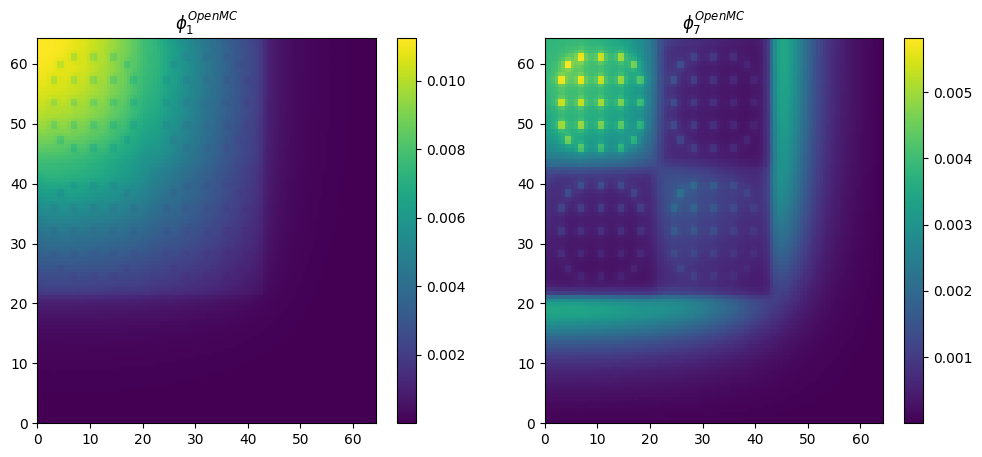

In [3]:
# OpenMC solutions
k_openmc = 1.18640
phi_openmc = loadmat("./data/reflective/phi_openmc.mat")["phi"]
print(f"Scalar flux shape: {phi_openmc.shape}")

# Ensure solution is normalized
phi_openmc /= np.linalg.norm(phi_openmc.flatten(), 2)

# Plot OpenMC fastest and slowest scalar flux
plt.clf()
plot_phi(phi_openmc, "$\\phi^{OpenMC}_1$", "$\\phi^{OpenMC}_7$")
plt.savefig("./figs/c5g7/phi_openmc.png", dpi=300)

## CPU AMEn

Below, we run power iteration in TT format with an Alternating Minimal Energy Method (AMEn) linear solver. The power iteration includes an outer iteration over the fission source and an inner iteration over the scattering source. The outer iteration is converged according to a Euclidean error,
$$
\epsilon_f > \frac{\| f^{(m_f + 1)} - f^{(m_f)}\|_2}{\|f^{(m_f)}\|_2},
$$
where $\epsilon_f = 10^{-5}$, $f = F\psi^{(m_f)}$, and $m_f$ is the outer iteration index. We set a maximum of $500$ outer iterations. The inner iteration is converged according to a Euclidean error,
$$
\epsilon_s > \frac{\| s^{(m_s + 1)} - s^{(m_s)}\|_2}{\|s^{(m_s)}\|_2},
$$
where $\epsilon_s = 10^{-4}$, $s^{(m_s)} = S\psi^{(m_s)} + f^{(m_f)}$, and $m_s$ is the scatter iteration index. There is a maximum of 30 scattering iterations. 

The AMEn solver starts with an initial rank two random guess in TT format and an initial residual TT of rank 4. Each AMEn call is converged to $10^{-6}$ on the local residuals with a maximum of 50 sweeps and a kickrank of four.

We compare the reflective boundary condition solution to OpenMC's solution using the following error metrics:
$$
\begin{gathered}
k\text{ relative error} = \frac{|k^{AMEn} - k^{OpenMC}|}{|k^{OpenMC}|},\\
\phi\text{ error} = \frac{\|\phi^{AMEn} - \phi^{OpenMC}\|_2}{\|\phi^{OpenMC}\|_2}.
\end{gathered}
$$
For the local error in scalar flux for the second figure below, we use a relative error,
$$
\phi_{i, j}\text{ relative error} = \frac{|\phi_{i, j}^{AMEn} - \phi_{i, j}^{OpenMC}|}{|\phi_{i, j}^{OpenMC}|}.
$$

In [4]:
# Power iteration configuration
eig_opts = {
    "tol": 1e-5,         # Fission source convergence tolerance
    "error_norm": "euc", # Use Euclidean error
    "max_iter": 500,
    "verbose": True,
    "use_gpu": False,
    "print_every": 5,
    "verbose": True,
}

# Scattering source iteration
scatter_iter_opts = {
    "tol": 1e-4,      # Scattering source convergence tolerance
    "max_iter": 30,
    "verbose": False,
}

### Reflective Boundaries

In [5]:
# Create initial guess for psi (rank 2) and residual (rank 4)
psi0 = MatrixProductState(
    [
        np.random.uniform(size=(num_ordinates, 2)),
        np.random.uniform(size=(2, num_groups, 2)),
        np.random.uniform(size=(2, num_cells + 1, 2)),
        np.random.uniform(size=(2, num_cells + 1)),
    ],
    shape="lpr",
)
z0 = MatrixProductState(
    [
        np.random.uniform(size=(num_ordinates, 4)),
        np.random.uniform(size=(4, num_groups, 4)),
        np.random.uniform(size=(4, num_cells + 1, 4)),
        np.random.uniform(size=(4, num_cells + 1)),
    ],
    shape="lpr",
)

# Normalize
psi0 /= (psi0.H @ psi0) ** 0.5
z0 /= (z0.H @ z0) ** 0.5

# AMEn solver
solver = AMEn(use_gpu=False, verbose=False)
solver_opts = {
    "z0": z0,
    "tol": 1e-6,
    "max_sweeps": 50,
    "virtual": True,
}

k, psi, phi, exec_time, _, _ = run_solver(
    num_ordinates=num_ordinates, 
    num_groups=num_groups, 
    num_cells_pin=num_cells_pin, 
    num_cells_mod=num_cells_mod, 
    xs_threshold=xs_threshold, 
    reflective_bc=True, 
    solver=solver, 
    solver_opts=solver_opts,
    eig_opts=eig_opts,
    scatter_iter_opts=scatter_iter_opts,
    psi0=psi0,
    verbose=True,
    save=True,
)
print(psi)

Discretization: G = 7, N = 4, I = 102, J = 102
Loss Operator
MatrixProductOperator([
    Tensor(shape=(16, 4, 4), inds=('_ed1ce3AAAAP', 'k0', 'b0'), tags=oset(['I0'])),
    Tensor(shape=(16, 28, 7, 7), inds=('_ed1ce3AAAAP', '_ed1ce3AAAAQ', 'k1', 'b1'), tags=oset(['I1'])),
    Tensor(shape=(28, 56, 103, 103), inds=('_ed1ce3AAAAQ', '_ed1ce3AAAAR', 'k2', 'b2'), tags=oset(['I2'])),
    Tensor(shape=(56, 103, 103), inds=('_ed1ce3AAAAR', 'k3', 'b3'), tags=oset(['I3'])),
], tensors=4, indices=11, L=4, max_bond=56)
Scattering Operator
MatrixProductOperator([
    Tensor(shape=(4, 4, 4), inds=('_ed1ce3AAAAT', 'k0', 'b0'), tags=oset(['I0'])),
    Tensor(shape=(4, 16, 7, 7), inds=('_ed1ce3AAAAT', '_ed1ce3AAAAU', 'k1', 'b1'), tags=oset(['I1'])),
    Tensor(shape=(16, 40, 103, 103), inds=('_ed1ce3AAAAU', '_ed1ce3AAAAV', 'k2', 'b2'), tags=oset(['I2'])),
    Tensor(shape=(40, 103, 103), inds=('_ed1ce3AAAAV', 'k3', 'b3'), tags=oset(['I3'])),
], tensors=4, indices=11, L=4, max_bond=40)
Fission Operator


/home/myerspat/research/tensor_trains/tt_nte/tt_nte/experimental/solvers/eig2.py:139: UserWarning: Scattering source iteration failed to converge for iteration 0
  warnings.warn(


-- (0): k = 0.93013123, |df|/|f| = 22.6361441, Elapsed Time = 3014.28587


/home/myerspat/research/tensor_trains/tt_nte/tt_nte/experimental/solvers/eig2.py:139: UserWarning: Scattering source iteration failed to converge for iteration 1
  warnings.warn(
/home/myerspat/research/tensor_trains/tt_nte/tt_nte/experimental/solvers/eig2.py:139: UserWarning: Scattering source iteration failed to converge for iteration 2
  warnings.warn(
/home/myerspat/research/tensor_trains/tt_nte/tt_nte/experimental/solvers/eig2.py:139: UserWarning: Scattering source iteration failed to converge for iteration 3
  warnings.warn(
/home/myerspat/research/tensor_trains/tt_nte/tt_nte/experimental/solvers/eig2.py:139: UserWarning: Scattering source iteration failed to converge for iteration 4
  warnings.warn(
/home/myerspat/research/tensor_trains/tt_nte/tt_nte/experimental/solvers/eig2.py:139: UserWarning: Scattering source iteration failed to converge for iteration 5
  warnings.warn(


-- (5): k = 1.15710127, |df|/|f| = 0.04860155, Elapsed Time = 13062.86553


...

-- (180): k = 1.18682783, |df|/|f| = 1.22e-05, Elapsed Time = 36911.44613


-- (185): k = 1.18683665, |df|/|f| = 1.153e-05, Elapsed Time = 36982.31812


-- (190): k = 1.18684496, |df|/|f| = 1.089e-05, Elapsed Time = 37052.18064


-- (195): k = 1.1868528, |df|/|f| = 1.028e-05, Elapsed Time = 37122.01093


-- Converged: k = 1.18685729, Elapsed Time = 37163.04858
MatrixProductState([
    Tensor(shape=(4, 4), inds=('_ed1ce3AAOlu', 'k0'), tags=oset(['I0'])),
    Tensor(shape=(4, 28, 7), inds=('_ed1ce3AAOlu', '_ed1ce3AAOlv', 'k1'), tags=oset(['I1'])),
    Tensor(shape=(28, 103, 103), inds=('_ed1ce3AAOlv', '_ed1ce3AAOlw', 'k2'), tags=oset(['I2'])),
    Tensor(shape=(103, 103), inds=('_ed1ce3AAOlw', 'k3'), tags=oset(['I3'])),
], tensors=4, indices=7, L=4, max_bond=103)


Time = 37163.118 s, k = 1.186857, k rel error = 0.000385, phi error = 0.02522


<Figure size 640x480 with 0 Axes>

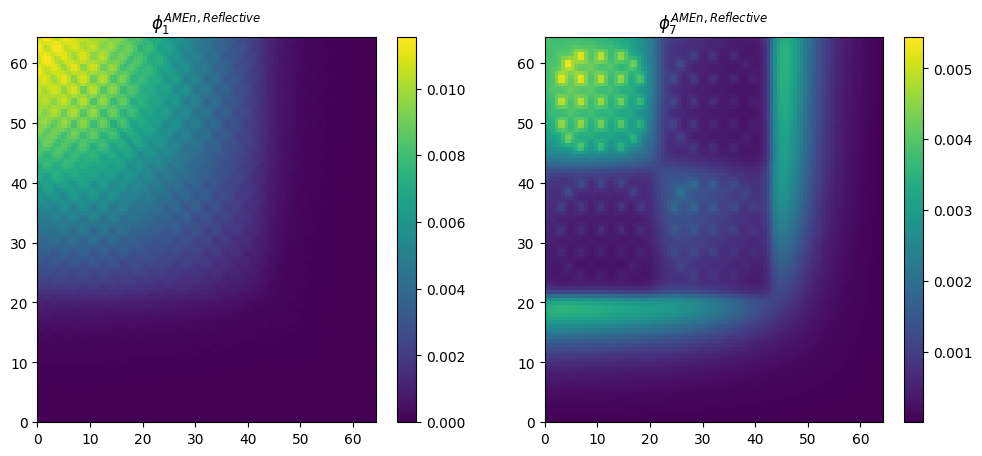

<Figure size 640x480 with 0 Axes>

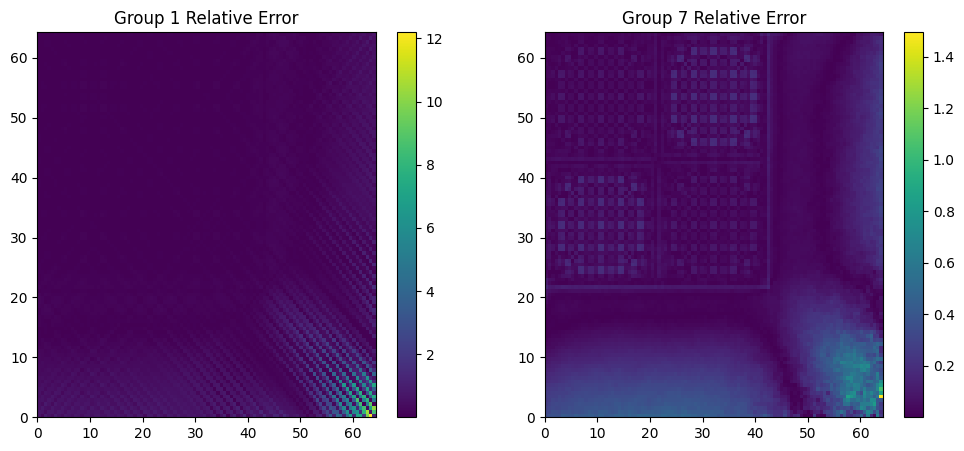

In [6]:
# Print results
print(
    "Time = {} s, k = {}, k rel error = {}, phi error = {}".format(
        round(exec_time, 3), 
        round(k, 6), 
        round(abs(k - k_openmc) / k_openmc, 6),
        round(np.linalg.norm((phi - phi_openmc).flatten(), 2), 6),
    )
)

# Plot scalar flux
plt.clf()
plot_phi(
    phi, 
    "$\\phi_1^{AMEn, Reflective}$",
    "$\\phi_7^{AMEn, Reflective}$",
)
plt.savefig("./figs/c5g7/phi_ref_amen.png", dpi=300)
plt.show()

# Plot error
plt.clf()
plot_phi(
    np.abs(phi - phi_openmc) / phi_openmc, 
    "Group 1 Relative Error", 
    "Group 7 Relative Error",
)
plt.savefig("./figs/c5g7/phi_ref_relerror_amen.png", dpi=300)
plt.show()

# Save amen solution
savemat(f"./data/reflective/psi.mat", {f"c{i}": psi[i].data for i in range(psi.L)})

For the reflective boundary condition case with an AMEn linear solver, the total execution time was greater than $10$ hours. The eigenvalue, relative error, and scalar flux error are shown above. The converged eigenvalue was 0.0385% off that found by OpenMC, with most of the errors occurring in the MOX fuel and reflector regions. Much of the reflector region errors occur where the flux is negligible.  

### Vacuum Boundaries

For the vacuum boundary case, we do not compare its solution to OpenMC, as our reference solution uses reflective boundaries.

In [7]:
# Create initial guess for psi (rank 2) and residual (rank 4)
psi0 = MatrixProductState(
    [
        np.random.uniform(size=(num_ordinates, 2)),
        np.random.uniform(size=(2, num_groups, 2)),
        np.random.uniform(size=(2, num_cells + 1, 2)),
        np.random.uniform(size=(2, num_cells + 1)),
    ],
    shape="lpr",
)
z0 = MatrixProductState(
    [
        np.random.uniform(size=(num_ordinates, 4)),
        np.random.uniform(size=(4, num_groups, 4)),
        np.random.uniform(size=(4, num_cells + 1, 4)),
        np.random.uniform(size=(4, num_cells + 1)),
    ],
    shape="lpr",
)

# Normalize
psi0 /= (psi0.H @ psi0) ** 0.5
z0 /= (z0.H @ z0) ** 0.5

# AMEn solver
solver = AMEn(use_gpu=False, verbose=False)
solver_opts = {
    "z0": z0,
    "tol": 1e-6,
    "max_sweeps": 50,
    "virtual": True,
}

k, psi, phi, exec_time, _, _ = run_solver(
    num_ordinates=num_ordinates, 
    num_groups=num_groups, 
    num_cells_pin=num_cells_pin, 
    num_cells_mod=num_cells_mod, 
    xs_threshold=xs_threshold, 
    reflective_bc=False, 
    solver=solver,
    solver_opts=solver_opts,
    eig_opts=eig_opts,
    scatter_iter_opts=scatter_iter_opts,
    psi0=psi0,
    verbose=True,
    save=True,
)

Discretization: G = 7, N = 4, I = 102, J = 102
Loss Operator
MatrixProductOperator([
    Tensor(shape=(12, 4, 4), inds=('_ed1ce3AAOmq', 'k0', 'b0'), tags=oset(['I0'])),
    Tensor(shape=(12, 24, 7, 7), inds=('_ed1ce3AAOmq', '_ed1ce3AAOmr', 'k1', 'b1'), tags=oset(['I1'])),
    Tensor(shape=(24, 52, 103, 103), inds=('_ed1ce3AAOmr', '_ed1ce3AAOms', 'k2', 'b2'), tags=oset(['I2'])),
    Tensor(shape=(52, 103, 103), inds=('_ed1ce3AAOms', 'k3', 'b3'), tags=oset(['I3'])),
], tensors=4, indices=11, L=4, max_bond=52)
Scattering Operator
MatrixProductOperator([
    Tensor(shape=(4, 4, 4), inds=('_ed1ce3AAOmu', 'k0', 'b0'), tags=oset(['I0'])),
    Tensor(shape=(4, 16, 7, 7), inds=('_ed1ce3AAOmu', '_ed1ce3AAOmv', 'k1', 'b1'), tags=oset(['I1'])),
    Tensor(shape=(16, 40, 103, 103), inds=('_ed1ce3AAOmv', '_ed1ce3AAOmw', 'k2', 'b2'), tags=oset(['I2'])),
    Tensor(shape=(40, 103, 103), inds=('_ed1ce3AAOmw', 'k3', 'b3'), tags=oset(['I3'])),
], tensors=4, indices=11, L=4, max_bond=40)
Fission Operator


Loss Operator
MatrixProductOperator([
    Tensor(shape=(12, 4, 4), inds=('_ed1ce3AAOmq', 'k0', 'b0'), tags=oset(['I0'])),
    Tensor(shape=(12, 24, 7, 7), inds=('_ed1ce3AAOmq', '_ed1ce3AAOmr', 'k1', 'b1'), tags=oset(['I1'])),
    Tensor(shape=(24, 52, 103, 103), inds=('_ed1ce3AAOmr', '_ed1ce3AAOms', 'k2', 'b2'), tags=oset(['I2'])),
    Tensor(shape=(52, 103, 103), inds=('_ed1ce3AAOms', 'k3', 'b3'), tags=oset(['I3'])),
], tensors=4, indices=11, L=4, max_bond=52)
Scattering Operator
MatrixProductOperator([
    Tensor(shape=(4, 4, 4), inds=('_ed1ce3AAOmu', 'k0', 'b0'), tags=oset(['I0'])),
    Tensor(shape=(4, 16, 7, 7), inds=('_ed1ce3AAOmu', '_ed1ce3AAOmv', 'k1', 'b1'), tags=oset(['I1'])),
    Tensor(shape=(16, 40, 103, 103), inds=('_ed1ce3AAOmv', '_ed1ce3AAOmw', 'k2', 'b2'), tags=oset(['I2'])),
    Tensor(shape=(40, 103, 103), inds=('_ed1ce3AAOmw', 'k3', 'b3'), tags=oset(['I3'])),
], tensors=4, indices=11, L=4, max_bond=40)
Fission Operator
MatrixProductOperator([
    Tensor(shape=(4, 4,

Starting power iteration


-- (0): k = 0.76216934, |df|/|f| = 1.14965107, Elapsed Time = 2402.5763


-- (5): k = 0.96974794, |df|/|f| = 0.02530679, Elapsed Time = 11108.64528


...

-- (145): k = 0.97543158, |df|/|f| = 1.264e-05, Elapsed Time = 22351.73742


-- (150): k = 0.9754349, |df|/|f| = 1.189e-05, Elapsed Time = 22412.80611


-- (155): k = 0.97543803, |df|/|f| = 1.119e-05, Elapsed Time = 22472.50143


-- (160): k = 0.97544099, |df|/|f| = 1.053e-05, Elapsed Time = 22532.31375


-- (165): k = 0.97544376, |df|/|f| = 9.91e-06, Elapsed Time = 22591.26163
-- Converged: k = 0.97544376, Elapsed Time = 22591.26185


Time = 22591.303 s, k = 0.975444


<Figure size 640x480 with 0 Axes>

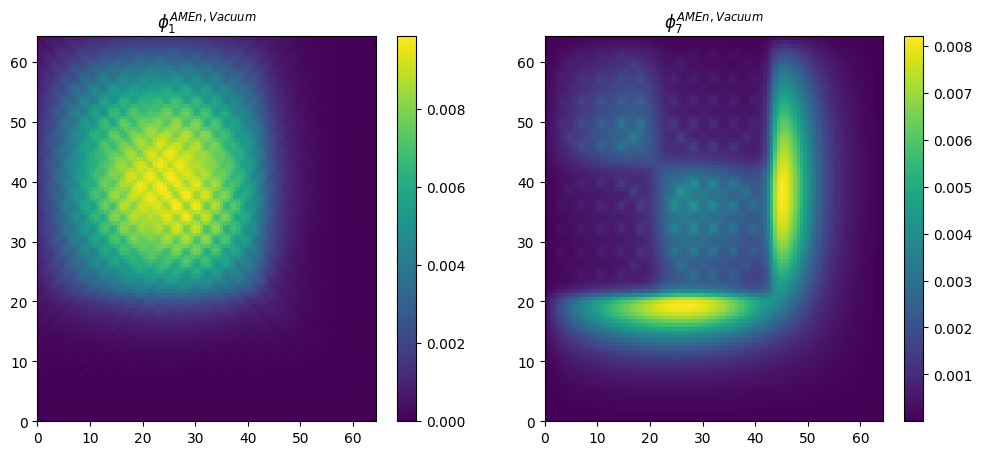

In [8]:
# Print results
print(
    "Time = {} s, k = {}".format(
        round(exec_time, 3),
        round(k, 6),
    )
)

# Plot scalar flux
plt.clf()
plot_phi(
    phi, 
    "$\\phi_1^{AMEn, Vacuum}$", 
    "$\\phi_7^{AMEn, Vacuum}$",
)
plt.savefig("./figs/c5g7/phi_vac_amen.png", dpi=300)

# Save amen solution
savemat(f"./data/vacuum/psi.mat", {f"c{i}": psi[i].data for i in range(psi.L)})

The above converged to $k = 0.97544$ in a little over $6$ hours.

## GMRES with Linear Operator

Instead of using an optimization approach for each local problem created from the projection to each dimension as AMEn does, we can treat the TT operators as black box linear operators with a standard approach to solving linear systems. This means the solution, the angular flux $\psi$, will be in vector form instead of TT format; however, more complicated systems require full rank anyway. Our memory benefits are then achieved through the compression of the operators. We use GMRES as our linear solver with power iteration on GPU. Each GMRES call is converged to a relative tolerance of $10^{-6}$ with a maximum of 2 iterations and 5 restarts. The configuration of the power iteration is the same as in the AMEn case.

In [9]:
# Use GPU for linear operator treatment
eig_opts["use_gpu"] = True

# GMRES
solver = GMRES(use_gpu=eig_opts["use_gpu"])
solver_opts = {
    "rtol": 1e-6,
    "max_iter": 2,
    "restart": 5,
}

### Reflective Boundaries

In [10]:
k, psi, phi, exec_time, _, _ = run_solver(
    num_ordinates=num_ordinates, 
    num_groups=num_groups, 
    num_cells_pin=num_cells_pin, 
    num_cells_mod=num_cells_mod, 
    xs_threshold=xs_threshold, 
    reflective_bc=True,
    solver=solver,
    solver_opts=solver_opts,
    eig_opts=eig_opts,
    scatter_iter_opts=scatter_iter_opts,
    psi0=None,
    verbose=True,
    save=False,
)
print(psi)

Discretization: G = 7, N = 4, I = 102, J = 102
Loss Operator
MatrixProductOperator([
    Tensor(shape=(16, 4, 4), inds=('_ed1ce3AAale', 'k0', 'b0'), tags=oset(['I0'])),
    Tensor(shape=(16, 28, 7, 7), inds=('_ed1ce3AAale', '_ed1ce3AAalf', 'k1', 'b1'), tags=oset(['I1'])),
    Tensor(shape=(28, 56, 103, 103), inds=('_ed1ce3AAalf', '_ed1ce3AAalg', 'k2', 'b2'), tags=oset(['I2'])),
    Tensor(shape=(56, 103, 103), inds=('_ed1ce3AAalg', 'k3', 'b3'), tags=oset(['I3'])),
], tensors=4, indices=11, L=4, max_bond=56)
Scattering Operator
MatrixProductOperator([
    Tensor(shape=(4, 4, 4), inds=('_ed1ce3AAali', 'k0', 'b0'), tags=oset(['I0'])),
    Tensor(shape=(4, 16, 7, 7), inds=('_ed1ce3AAali', '_ed1ce3AAalj', 'k1', 'b1'), tags=oset(['I1'])),
    Tensor(shape=(16, 40, 103, 103), inds=('_ed1ce3AAalj', '_ed1ce3AAalk', 'k2', 'b2'), tags=oset(['I2'])),
    Tensor(shape=(40, 103, 103), inds=('_ed1ce3AAalk', 'k3', 'b3'), tags=oset(['I3'])),
], tensors=4, indices=11, L=4, max_bond=40)
Fission Operator


/home/myerspat/research/tensor_trains/tt_nte/tt_nte/experimental/solvers/eig2.py:188: UserWarning: Fission iteration 3 error is greater than iteration 2
  warnings.warn(
/home/myerspat/research/tensor_trains/tt_nte/tt_nte/experimental/solvers/eig2.py:188: UserWarning: Fission iteration 4 error is greater than iteration 3
  warnings.warn(


-- (5): k = 2.91831038, |df|/|f| = 0.55926142, Elapsed Time = 114.83631


/home/myerspat/research/tensor_trains/tt_nte/tt_nte/experimental/solvers/eig2.py:188: UserWarning: Fission iteration 6 error is greater than iteration 5
  warnings.warn(


-- (10): k = 1.28637662, |df|/|f| = 0.18502819, Elapsed Time = 210.54481
-- (15): k = 1.21698851, |df|/|f| = 0.06143786, Elapsed Time = 306.25317


...

-- (185): k = 1.18715652, |df|/|f| = 1.187e-05, Elapsed Time = 732.67827


-- (190): k = 1.1871477, |df|/|f| = 1.125e-05, Elapsed Time = 736.22852


-- (195): k = 1.18713935, |df|/|f| = 1.066e-05, Elapsed Time = 739.77859


-- (200): k = 1.18713143, |df|/|f| = 1.011e-05, Elapsed Time = 743.32893


-- Converged: k = 1.1871299, Elapsed Time = 744.07628
MatrixProductState([
    Tensor(shape=(4, 4), inds=('k0', '_ed1ce3AAamJ'), tags=oset(['I0']), left_inds=('k0',)),
    Tensor(shape=(4, 7, 28), inds=('_ed1ce3AAamJ', 'k1', '_ed1ce3AAamK'), tags=oset(['I1']), left_inds=('_ed1ce3AAamJ', 'k1')),
    Tensor(shape=(28, 103, 103), inds=('_ed1ce3AAamK', 'k2', '_ed1ce3AAamL'), tags=oset(['I2']), left_inds=('_ed1ce3AAamK', 'k2')),
    Tensor(shape=(103, 103), inds=('_ed1ce3AAamL', 'k3'), tags=oset(['I3'])),
], tensors=4, indices=7, L=4, max_bond=103)


Time = 744.515 s, k = 1.18713, k rel error = 0.000615, phi error = 0.025322


<Figure size 640x480 with 0 Axes>

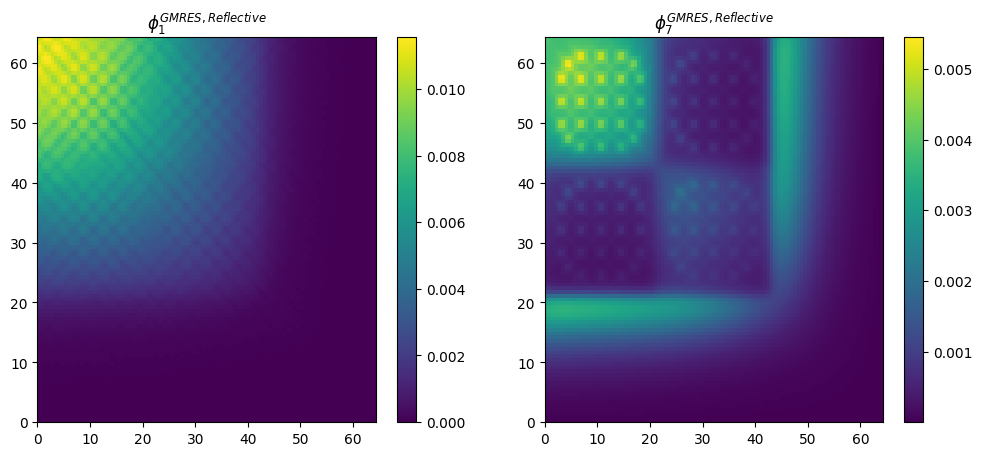

<Figure size 640x480 with 0 Axes>

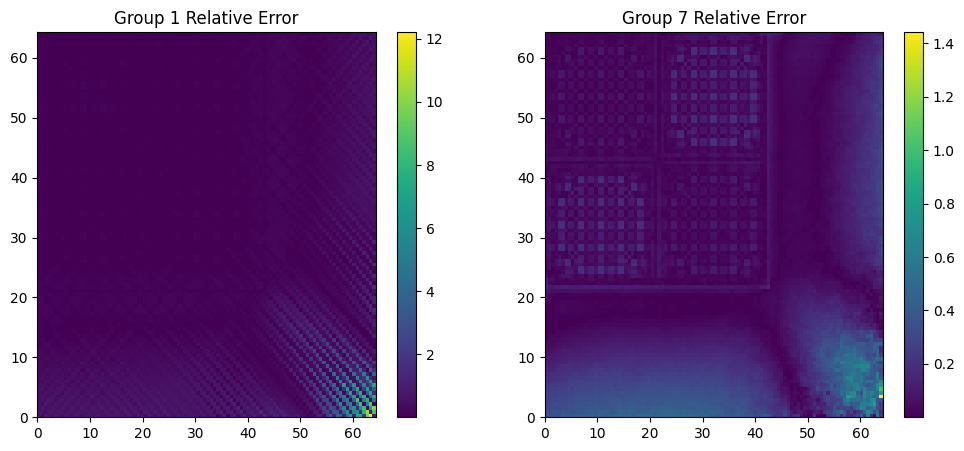

In [11]:
# Print results
print(
    "Time = {} s, k = {}, k rel error = {}, phi error = {}".format(
        round(exec_time, 3), 
        round(k, 6), 
        round(abs(k - k_openmc) / k_openmc, 6),
        round(np.linalg.norm((phi - phi_openmc).flatten(), 2), 6),
    )
)

# Plot scalar flux
plt.clf()
plot_phi(
    phi, 
    "$\\phi_1^{GMRES, Reflective}$",
    "$\\phi_7^{GMRES, Reflective}$",
)
plt.savefig("./figs/c5g7/phi_ref_gmres.png", dpi=300)
plt.show()

# Plot error
plt.clf()
plot_phi(
    np.abs(phi - phi_openmc) / phi_openmc, 
    "Group 1 Relative Error", 
    "Group 7 Relative Error",
)
plt.savefig("./figs/c5g7/phi_ref_relerror_gmres.png", dpi=300)
plt.show()

In this case, we see the eigenvalue is $0.0685\%$ off the OpenMC solution with an execution time of $12.4$ minutes. The discrepancy in eigenvalue compared to the AMEn approach is likely due to the random initial guess. This approach is considerably faster than AMEn; however, in this approach we fully utilized a GPU for all computations.

### Vacuum Boundaries

In [12]:
k, psi, phi, exec_time, _, _ = run_solver(
    num_ordinates=num_ordinates, 
    num_groups=num_groups, 
    num_cells_pin=num_cells_pin, 
    num_cells_mod=num_cells_mod, 
    xs_threshold=xs_threshold, 
    reflective_bc=False,
    solver=solver,
    solver_opts=solver_opts,
    eig_opts=eig_opts,
    scatter_iter_opts=scatter_iter_opts,
    psi0=None,
    verbose=True,
    save=False,
)
print(psi)

Discretization: G = 7, N = 4, I = 102, J = 102
Loss Operator
MatrixProductOperator([
    Tensor(shape=(12, 4, 4), inds=('_ed1ce3AAamO', 'k0', 'b0'), tags=oset(['I0'])),
    Tensor(shape=(12, 24, 7, 7), inds=('_ed1ce3AAamO', '_ed1ce3AAamP', 'k1', 'b1'), tags=oset(['I1'])),
    Tensor(shape=(24, 52, 103, 103), inds=('_ed1ce3AAamP', '_ed1ce3AAamQ', 'k2', 'b2'), tags=oset(['I2'])),
    Tensor(shape=(52, 103, 103), inds=('_ed1ce3AAamQ', 'k3', 'b3'), tags=oset(['I3'])),
], tensors=4, indices=11, L=4, max_bond=52)
Scattering Operator
MatrixProductOperator([
    Tensor(shape=(4, 4, 4), inds=('_ed1ce3AAamS', 'k0', 'b0'), tags=oset(['I0'])),
    Tensor(shape=(4, 16, 7, 7), inds=('_ed1ce3AAamS', '_ed1ce3AAamT', 'k1', 'b1'), tags=oset(['I1'])),
    Tensor(shape=(16, 40, 103, 103), inds=('_ed1ce3AAamT', '_ed1ce3AAamU', 'k2', 'b2'), tags=oset(['I2'])),
    Tensor(shape=(40, 103, 103), inds=('_ed1ce3AAamU', 'k3', 'b3'), tags=oset(['I3'])),
], tensors=4, indices=11, L=4, max_bond=40)
Fission Operator


/home/myerspat/research/tensor_trains/tt_nte/tt_nte/experimental/solvers/eig2.py:188: UserWarning: Fission iteration 1 error is greater than iteration 0
  warnings.warn(


-- (5): k = 1.01490505, |df|/|f| = 0.19326298, Elapsed Time = 94.6906
-- (10): k = 0.97957155, |df|/|f| = 0.04231398, Elapsed Time = 173.58966
-- (15): k = 0.97652797, |df|/|f| = 0.01167923, Elapsed Time = 252.48904
-- (20): k = 0.97580443, |df|/|f| = 0.00330088, Elapsed Time = 331.39002
-- (25): k = 0.97564321, |df|/|f| = 0.0002869, Elapsed Time = 384.63894
-- (30): k = 0.97564273, |df|/|f| = 5.929e-05, Elapsed Time = 389.72268
-- (35): k = 0.97564019, |df|/|f| = 5.527e-05, Elapsed Time = 392.71221
-- (40): k = 0.97563624, |df|/|f| = 5.191e-05, Elapsed Time = 395.7019
-- (45): k = 0.97563119, |df|/|f| = 4.85e-05, Elapsed Time = 398.6914
-- (50): k = 0.97562534, |df|/|f| = 4.494e-05, Elapsed Time = 401.68091
-- (55): k = 0.97561908, |df|/|f| = 4.164e-05, Elapsed Time = 404.67064
-- (60): k = 0.97561271, |df|/|f| = 3.874e-05, Elapsed Time = 407.66019
-- (65): k = 0.9756064, |df|/|f| = 3.616e-05, Elapsed Time = 410.64988
-- (70): k = 0.97560024, |df|/|f| = 3.377e-05, Elapsed Time = 413.6

/home/myerspat/research/tensor_trains/tt_nte/tt_nte/experimental/solvers/eig2.py:188: UserWarning: Fission iteration 1 error is greater than iteration 0
  warnings.warn(


-- (5): k = 1.01490505, |df|/|f| = 0.19326298, Elapsed Time = 94.6906


...

-- (150): k = 0.97553397, |df|/|f| = 1.208e-05, Elapsed Time = 461.4745


-- (155): k = 0.9755315, |df|/|f| = 1.136e-05, Elapsed Time = 464.46414


-- (160): k = 0.97552917, |df|/|f| = 1.069e-05, Elapsed Time = 467.45397


-- (165): k = 0.97552697, |df|/|f| = 1.006e-05, Elapsed Time = 470.44364


-- Converged: k = 0.97552655, Elapsed Time = 471.07881
MatrixProductState([
    Tensor(shape=(4, 4), inds=('k0', '_ed1ce3AAamt'), tags=oset(['I0']), left_inds=('k0',)),
    Tensor(shape=(4, 7, 28), inds=('_ed1ce3AAamt', 'k1', '_ed1ce3AAamu'), tags=oset(['I1']), left_inds=('_ed1ce3AAamt', 'k1')),
    Tensor(shape=(28, 103, 103), inds=('_ed1ce3AAamu', 'k2', '_ed1ce3AAamv'), tags=oset(['I2']), left_inds=('_ed1ce3AAamu', 'k2')),
    Tensor(shape=(103, 103), inds=('_ed1ce3AAamv', 'k3'), tags=oset(['I3'])),
], tensors=4, indices=7, L=4, max_bond=103)


Time = 471.202 s, k = 0.975527


<Figure size 640x480 with 0 Axes>

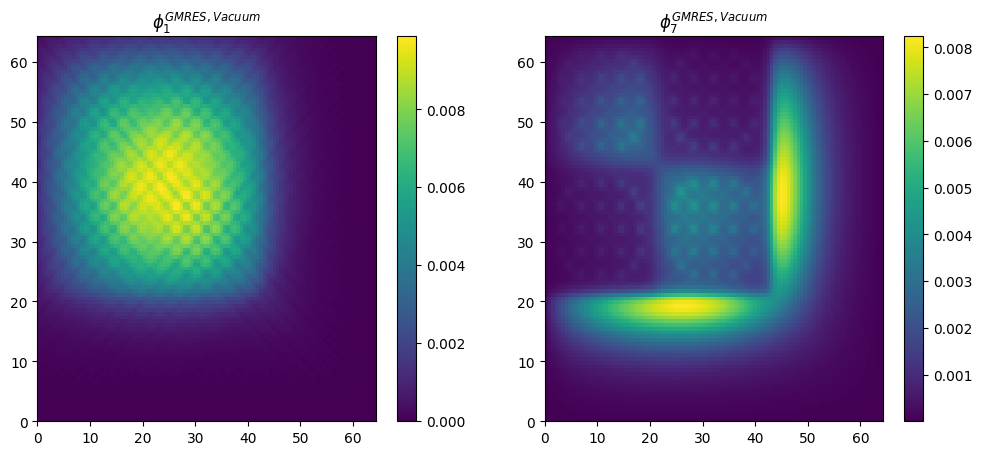

In [13]:
# Print results
print(
    "Time = {} s, k = {}".format(
        round(exec_time, 3),
        round(k, 6),
    )
)

# Plot scalar flux
plt.clf()
plot_phi(
    phi, 
    "$\\phi_1^{GMRES, Vacuum}$", 
    "$\\phi_7^{GMRES, Vacuum}$",
)
plt.savefig("./figs/c5g7/phi_vac_gmres.png", dpi=300)

Using GMRES, we found $k = 0.975527$, which is close to that found using AMEn, in $7.85$ minutes.

### Effect of Compression

Using GMRES with linear operators, we can plot its performance as a function of XS operator compression. Below, we look at the eigenvalue, eigenvalue relative error, scalar flux error, CPU and GPU execution times, ranks, and operator compression as the XS operator compression decreases from $10^{-2}$ to $10^{-9}$.

In [14]:
# Turn off verbose in power iteration
eig_opts["verbose"] = False

# XS compression thresholds
xs_thresholds = 10 ** -np.arange(2, 10, dtype=float)

# Data
data = {
    "k": [], 
    "k rel error": [], 
    "phi error": [],
    "cpu time": [],
    "gpu time": [],
    "H_ranks": [], 
    "S_ranks": [], 
    "F_ranks": [],
    "H_size": [], 
    "S_size": [], 
    "F_size": []
}

# Initial guess
psi0 = np.ones(int(num_ordinates * num_groups * (num_cells + 1) ** 2))
psi0 /= np.linalg.norm(psi0, 2)
k0 = 1.0

# Run through each compression
for xs_threshold in xs_thresholds:
    print(f"Compression = {xs_threshold},", end=" ")
    (
        k, 
        _, 
        phi, 
        exec_time, 
        (H_ranks, S_ranks, F_ranks), 
        (H_size, S_size, F_size),
    ) = run_solver(
        num_ordinates=num_ordinates, 
        num_groups=num_groups, 
        num_cells_pin=num_cells_pin, 
        num_cells_mod=num_cells_mod, 
        xs_threshold=xs_threshold, 
        reflective_bc=True,
        solver=solver,
        solver_opts=solver_opts,
        eig_opts=eig_opts,
        scatter_iter_opts=scatter_iter_opts,
        psi0=psi0,
        k0 = k0,
        verbose=False,
        save=False,
    )

    # Save results
    data["k"].append(k)
    data["k rel error"].append(abs(k - k_openmc) / k_openmc)
    data["phi error"].append(np.linalg.norm((phi - phi_openmc).flatten(), 2))
    data["gpu time"].append(exec_time)
    data["H_ranks"].append(H_ranks)
    data["S_ranks"].append(S_ranks)
    data["F_ranks"].append(F_ranks)
    data["H_size"].append(H_size)
    data["S_size"].append(S_size)
    data["F_size"].append(F_size)

    # Print results
    print(
        "Time = {} s, k = {}, k rel error = {}, phi error = {}".format(
            round(exec_time, 3), 
            round(k, 6), 
            round(abs(k - k_openmc) / k_openmc, 6),
            round(np.linalg.norm((phi - phi_openmc).flatten(), 2), 6),
        )
    )

Compression = 0.01, Time = 227.987 s, k = 1.172472, k rel error = 0.01174, phi error = 0.262105
Compression = 0.001, Time = 563.795 s, k = 1.186836, k rel error = 0.000368, phi error = 0.025217
Compression = 0.0001, Time = 824.469 s, k = 1.1858, k rel error = 0.000505, phi error = 0.025001
Compression = 1e-05, Time = 945.225 s, k = 1.185793, k rel error = 0.000511, phi error = 0.024998
Compression = 1e-06, Time = 1002.031 s, k = 1.185793, k rel error = 0.000511, phi error = 0.024998
Compression = 1e-07, Time = 1099.583 s, k = 1.185793, k rel error = 0.000511, phi error = 0.024998
Compression = 1e-08, Time = 1099.63 s, k = 1.185793, k rel error = 0.000511, phi error = 0.024998
Compression = 1e-09, Time = 1099.626 s, k = 1.185793, k rel error = 0.000511, phi error = 0.024998


Time = 227.987 s, k = 1.172472, k rel error = 0.01174, phi error = 0.262105
Compression = 0.001, 

Time = 563.795 s, k = 1.186836, k rel error = 0.000368, phi error = 0.025217
Compression = 0.0001, 

Time = 824.469 s, k = 1.1858, k rel error = 0.000505, phi error = 0.025001
Compression = 1e-05, 

Time = 945.225 s, k = 1.185793, k rel error = 0.000511, phi error = 0.024998
Compression = 1e-06, 

Time = 1002.031 s, k = 1.185793, k rel error = 0.000511, phi error = 0.024998
Compression = 1e-07, 

Time = 1099.583 s, k = 1.185793, k rel error = 0.000511, phi error = 0.024998
Compression = 1e-08, 

Time = 1099.63 s, k = 1.185793, k rel error = 0.000511, phi error = 0.024998
Compression = 1e-09, 

Time = 1099.626 s, k = 1.185793, k rel error = 0.000511, phi error = 0.024998


In [15]:
# Use CPU for linear operator treatment
eig_opts["use_gpu"] = False

# GMRES
solver = GMRES(use_gpu=eig_opts["use_gpu"])
solver_opts = {
    "rtol": 1e-6,
    "max_iter": 2,
    "restart": 5,
}

# Run through each compression
for xs_threshold in xs_thresholds:
    print(f"Compression = {xs_threshold},", end=" ")
    (
        _, 
        _, 
        _, 
        exec_time, 
        _, 
        _,
    ) = run_solver(
        num_ordinates=num_ordinates, 
        num_groups=num_groups, 
        num_cells_pin=num_cells_pin, 
        num_cells_mod=num_cells_mod, 
        xs_threshold=xs_threshold, 
        reflective_bc=True,
        solver=solver,
        solver_opts=solver_opts,
        eig_opts=eig_opts,
        scatter_iter_opts=scatter_iter_opts,
        psi0=psi0,
        k0 = k0,
        verbose=False,
        save=False,
    )

    # Save time
    data["cpu time"].append(exec_time)

    # Print results
    print("Time = {} s".format(round(exec_time, 3)))

Compression = 0.01, Time = 1288.724 s
Compression = 0.001, Time = 2754.092 s
Compression = 0.0001, Time = 3711.022 s
Compression = 1e-05, Time = 4041.882 s
Compression = 1e-06, Time = 4145.626 s
Compression = 1e-07, Time = 4519.892 s
Compression = 1e-08, Time = 4525.438 s
Compression = 1e-09, Time = 4522.905 s


Time = 1288.724 s
Compression = 0.001, 

Time = 2754.092 s
Compression = 0.0001, 

Time = 3711.022 s
Compression = 1e-05, 

Time = 4041.882 s
Compression = 1e-06, 

Time = 4145.626 s
Compression = 1e-07, 

Time = 4519.892 s
Compression = 1e-08, 

Time = 4525.438 s
Compression = 1e-09, 

Time = 4522.905 s


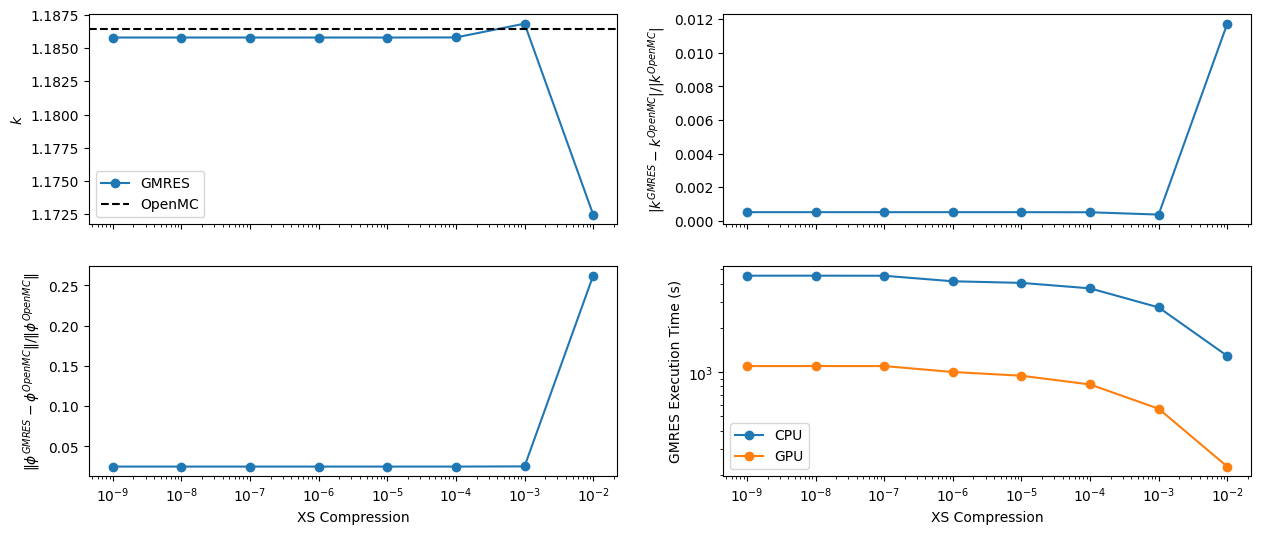

In [16]:
# Plot results
fig, axs = plt.subplots(2, 2, figsize=(15, 6), sharex=True)

# Eigenvalue plot
axs[0, 0].plot(xs_thresholds, data["k"], "-o", label="GMRES")
axs[0, 0].axhline(k_openmc, color="k", linestyle="--", label="OpenMC")
axs[0, 0].set_xscale("log")
axs[0, 0].set_ylabel("$k$")
axs[0, 0].legend()

# Eigenvalue relative error
axs[0, 1].plot(xs_thresholds, data["k rel error"], "-o")
axs[0, 1].set_xscale("log")
axs[0, 1].set_ylabel("$|k^{GMRES} - k^{OpenMC}|/|k^{OpenMC}|$")

# Scalar flux error
axs[1, 0].plot(xs_thresholds, data["phi error"], "-o")
axs[1, 0].set_xscale("log")
axs[1, 0].set_ylabel("$\\|\\phi^{GMRES} - \\phi^{OpenMC}\\| / \\|\\phi^{OpenMC}\\|$")
axs[1, 0].set_xlabel("XS Compression")

# Execution time
axs[1, 1].plot(xs_thresholds, data["cpu time"], "-o", label="CPU")
axs[1, 1].plot(xs_thresholds, data["gpu time"], "-o", label="GPU")
axs[1, 1].set_xscale("log")
axs[1, 1].set_yscale("log")
axs[1, 1].set_ylabel("GMRES Execution Time (s)")
axs[1, 1].set_xlabel("XS Compression")
axs[1, 1].legend()

plt.savefig("./figs/compress_results.png", dpi=300)
plt.show()

Above, we see little return in eigenvalue and scalar flux after $10^{-3}$ compression with close to $5\times$ speedup using GPU over CPU.

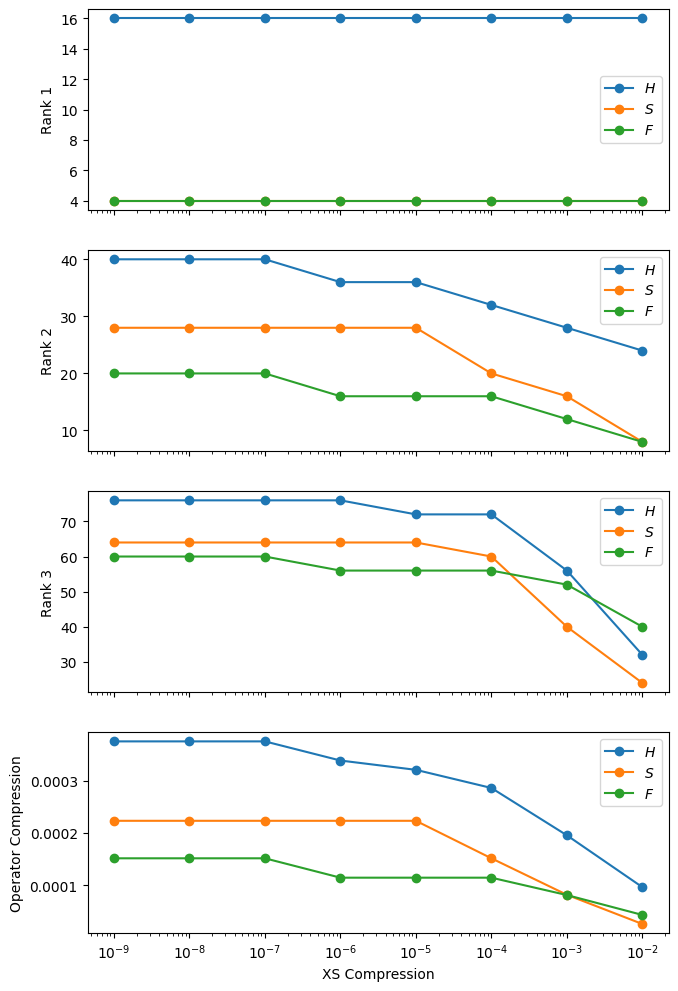

In [17]:
# Plot results
fig, axs = plt.subplots(4, 1, figsize=(7.5, 12), sharex=True)

for i in range(3):
    axs[i].plot(xs_thresholds, np.array(data["H_ranks"])[:, i], "-o", label="$H$")
    axs[i].plot(xs_thresholds, np.array(data["S_ranks"])[:, i], "-o", label="$S$")
    axs[i].plot(xs_thresholds, np.array(data["F_ranks"])[:, i], "-o", label="$F$")
    axs[i].set_xscale("log")
    axs[i].set_ylabel(f"Rank {i + 1}")
    axs[i].legend()

# Size of operators
axs[-1].plot(
    xs_thresholds, 
    np.array(data["H_size"]) / (num_groups * num_ordinates * (num_cells + 1) ** 2) ** 2, 
    "-o", 
    label="$H$"
)
axs[-1].plot(
    xs_thresholds, 
    np.array(data["S_size"]) / (num_groups * num_ordinates * (num_cells + 1) ** 2) ** 2, 
    "-o", 
    label="$S$"
)
axs[-1].plot(
    xs_thresholds, 
    np.array(data["F_size"]) / (num_groups * num_ordinates * (num_cells + 1) ** 2) ** 2, 
    "-o", 
    label="$F$"
)
axs[-1].set_xscale("log")
axs[-1].legend()
axs[-1].set_ylabel("Operator Compression")
axs[-1].set_xlabel("XS Compression")

plt.savefig("./figs/compress_results_ranks.png", dpi=300)
plt.show()

The ranks between the $x$ and $y$ spatial cores (Rank 3) hint at a greater coupling than the other two, as all operators almost asymptote at $10^{-4}$ compression. We note that while these are still relatively large ranks, there is still considerable compression to full matrix format.